# **A Quantitative Analysis of the Evolution of Shock Humor in South Park and its Reflections on Society Today**



---



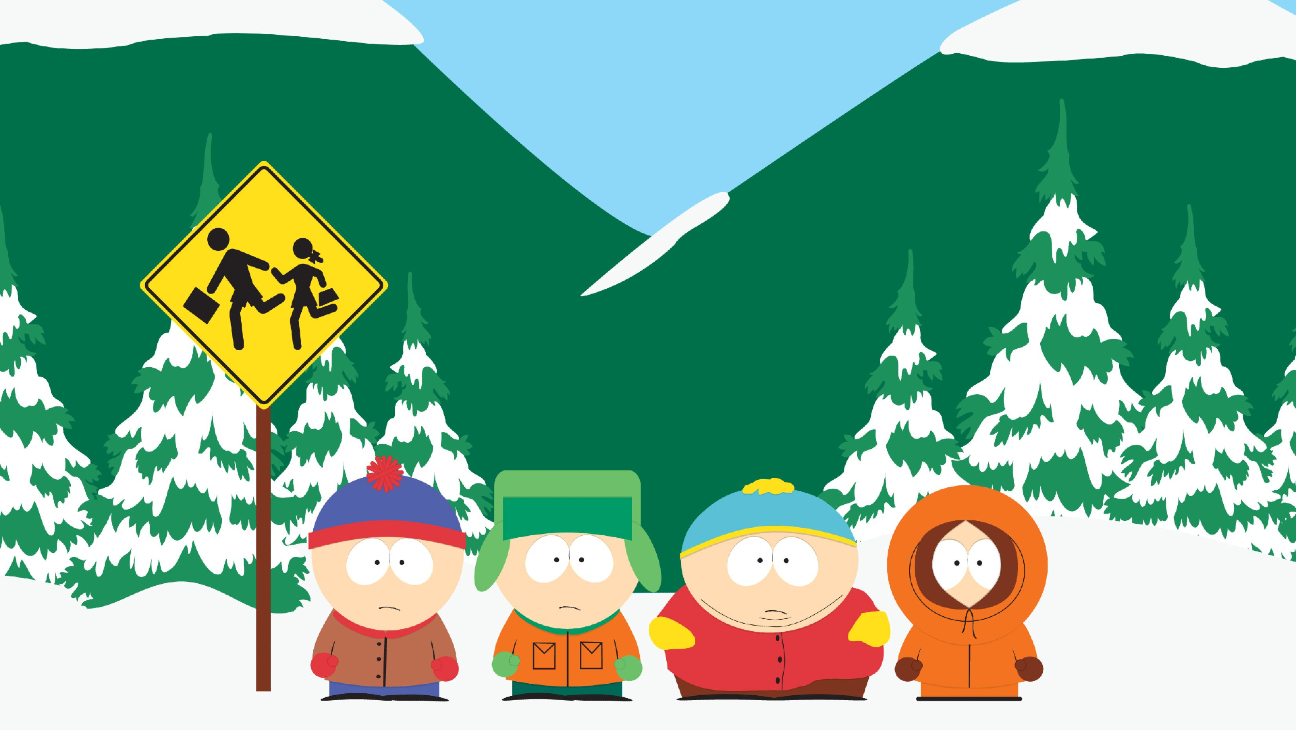

# ⛄ **About South Park:**
"South Park," created by Trey Parker and Matt Stone, is known for its controversial humor, which evolves over the years to reflect and comment on various aspects of contemporary society, offending various individuals and groups throughout its run. The show is particularly adept at addressing current events, cultural shifts, and societal trends. The evolution of humor in "South Park" can be seen as a reflection of, and commentary on, the changing landscape of society.



# 🤔 **About this project:**


Since South Park has managed to stay as a staple sitcom and consistent reflection of a dystopian society for over 20 years, I wanted to do an analysis on how its reliance on shock humor has changed over time. As South Park consistently seeks to push against offensive boundaries, gauging strong reactions from its audience through utilization of relevant controversial topics, changes in its implementation of certain shock value techniques may potentially unveil a nuanced societal commentary on society's desensitization to certain factors over others.

Thus, assuming that there is a correlation between a topic's appearance on South Park and its general relevance in society, we may be able to infer reasoning behind its trends.

# **Hypothesis:** Shock humor has gradually lost its effect over time.





# **South Park Dataset ⬇**

**Link:** https://www.kaggle.com/datasets/mustafacicek/south-park-scripts-dataset

**Description on Kaggle:**
This dataset contains two file.

SouthPark_Episodes.csv columns: Episode names, air date, season, episode number, and description of episode.
SouthPark_Lines.csv columns: Includes episode name, character and its line.

Includes data from over 300 episodes and over 95000 lines.



> First, let's import the data



In [ ]:
import pandas as pd
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [ ]:
episode_df = pd.read_csv('SouthPark_Episodes.csv')
episode_df.head(5)

,Title,Air Date,Code,#,Description,Season,Episode
0,Cartman Gets an Anal Probe,"August 13, 1997",101,1,"While the boys are waiting for the school bus,...",1,1
1,Weight Gain 4000,"August 20, 1997",102,2,When Cartman's environmental essay wins a nati...,1,2
2,Volcano,"August 27, 1997",103,3,A weekend trip to experience the finer points ...,1,3
3,Big Gay Al's Big Gay Boat Ride,"September 3, 1997",104,4,"When Stan discovers his new dog Sparky is gay,...",1,4
4,An Elephant Makes Love to a Pig,"September 10, 1997",105,5,"Kyle's mom won't let him keep his new pet, an ...",1,5


In [ ]:
lines_df = pd.read_csv('SouthPark_Lines.csv')
lines_df.head(5)

,Title,Character,Line
0,Cartman Gets an Anal Probe,Scene Description,At the bus stop.
1,Cartman Gets an Anal Probe,The Boys,"School days, school days, teacher's golden ru..."
2,Cartman Gets an Anal Probe,Kyle Broflovski,"Ah, damn it! My little brother's trying to fol..."
3,Cartman Gets an Anal Probe,Ike Broflovski,Eat banana.
4,Cartman Gets an Anal Probe,Kyle,"Ike, you can't come to school with me. [Ike Ch..."


In [ ]:
merged_df = pd.merge(episode_df, lines_df, on='Title')
merged_df.head(5)

,Title,Air Date,Code,#,Description,Season,Episode,Character,Line
0,Cartman Gets an Anal Probe,"August 13, 1997",101,1,"While the boys are waiting for the school bus,...",1,1,Scene Description,At the bus stop.
1,Cartman Gets an Anal Probe,"August 13, 1997",101,1,"While the boys are waiting for the school bus,...",1,1,The Boys,"School days, school days, teacher's golden ru..."
2,Cartman Gets an Anal Probe,"August 13, 1997",101,1,"While the boys are waiting for the school bus,...",1,1,Kyle Broflovski,"Ah, damn it! My little brother's trying to fol..."
3,Cartman Gets an Anal Probe,"August 13, 1997",101,1,"While the boys are waiting for the school bus,...",1,1,Ike Broflovski,Eat banana.
4,Cartman Gets an Anal Probe,"August 13, 1997",101,1,"While the boys are waiting for the school bus,...",1,1,Kyle,"Ike, you can't come to school with me. [Ike Ch..."



> Sentiment Analysis function (for later)




In [ ]:
def get_sentiment(line):
    compound_score = sid.polarity_scores(line)['compound']
    if compound_score > 0.2:
        return 'Positive'
    elif compound_score < -0.2:
        return 'Negative'
    else:
        return 'Neutral'

sid = SentimentIntensityAnalyzer()



> Now let's create some visualizations to analyze the trends and make conclusions



# 😠 **Part 1: Profanity**

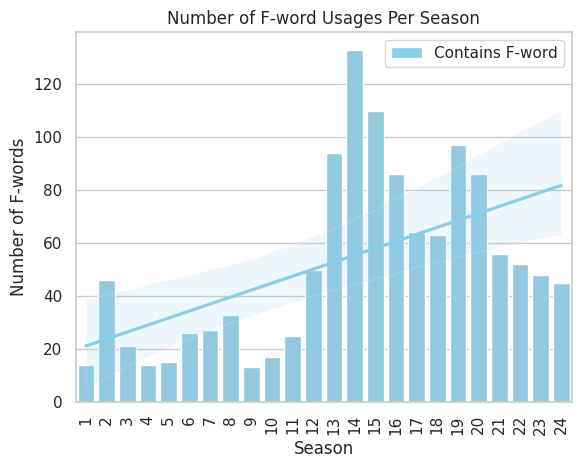

In [ ]:
def contains_f_word(line):
    if pd.isna(line):
        return 0
    return 1 if "fuck" in line.lower() else 0

merged_df['Contains F-word'] = merged_df['Line'].apply(contains_f_word)
season_counts = merged_df.groupby('Season')['Contains F-word'].sum()
season_counts.plot(kind='bar', color='skyblue')
ax = sns.barplot(x=season_counts.index, y=season_counts.values, color='skyblue')
sns.regplot(x=list(range(len(season_counts))), y=season_counts.values, ax=ax, scatter=False, color='skyblue', line_kws={'label': 'Regression Line'})
plt.xlabel('Season')
plt.ylabel('Number of F-words')
plt.title('Number of F-word Usages Per Season')
plt.legend()
plt.show()



> **"Language is constantly evolving, and fuck emphasizes that on a lingusitic level. We no longer exclusively associate the term with its former 16th century negativity because its meaning—just like people—has changed." -John Laudani https://theemeraldmagazine.com/history-of-the-word-fuck/**



In 1999, South Park made television history by boldly airing the uncensored version of the "F-word," sparking a massive reaction from viewers that ranged from outrage to praise. Over the years, societal attitudes toward language and content in media have shifted significantly. There's been a noticeable trend toward greater acceptance of explicit language and mature themes across various forms of entertainment. Profanity, once considered taboo, has now become commonplace and is often used as a cornerstone of modern "edgy humor."

As the initial shock value of such language has diminished since its debut on national television, South Park's frequent use of it serves as a testament to its normalization in contemporary society. In fact, using such language more extensively might now be necessary to recapture even a fraction of the impact it had during the show's early seasons.


#**😇 Part 2: Religion**

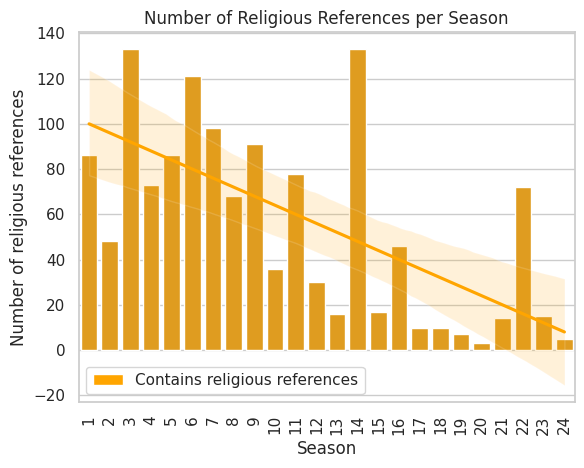

In [ ]:
religious_references = ['jesus', 'christianity', 'mormonism', 'scientology', 'l. ron hubbard',
    'islam', 'muhammad', 'judaism', 'hinduism', 'krishna',
    'buddhism', 'catholicism', 'priest scandal', 'vatican',
    'religious figures', 'pope','bible', 'religion', 'buddha',
    'joseph smith', 'moses', 'agnosticism', 'lao Tzu', 'taoism']

def contains_religion(line):
    if pd.isna(line):
      return 0
    for j in religious_references:
      if j in line.lower(): return 1
    return 0

merged_df['Contains religious references'] = merged_df['Line'].apply(contains_religion)
season_counts = merged_df.groupby('Season')['Contains religious references'].sum()
season_counts.plot(kind='bar', color='orange')
sns.set(style="whitegrid")
ax = sns.barplot(x=season_counts.index, y=season_counts.values, color='orange')
sns.regplot(x=list(range(len(season_counts))), y=season_counts.values, ax=ax, scatter=False, color='orange', line_kws={'label': 'Regression Line'})
plt.xlabel('Season')
plt.ylabel('Number of religious references')
plt.title('Number of Religious References per Season')
plt.legend()
plt.show()

Once a taboo topic, in recent years, discussions around religion have become increasingly diverse, and there is a growing emphasis on promoting understanding, tolerance, and respect for different religious beliefs. This has potentially led to religion becoming less and less of a "shocking" topic on television in general, which could potentially be the reason behind its decline on South Park's radar

<ipython-input-27-c989ae9e6ae3>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  religious_lines_df['SentimentCategory'] = religious_lines_df['Line'].apply(get_sentiment)


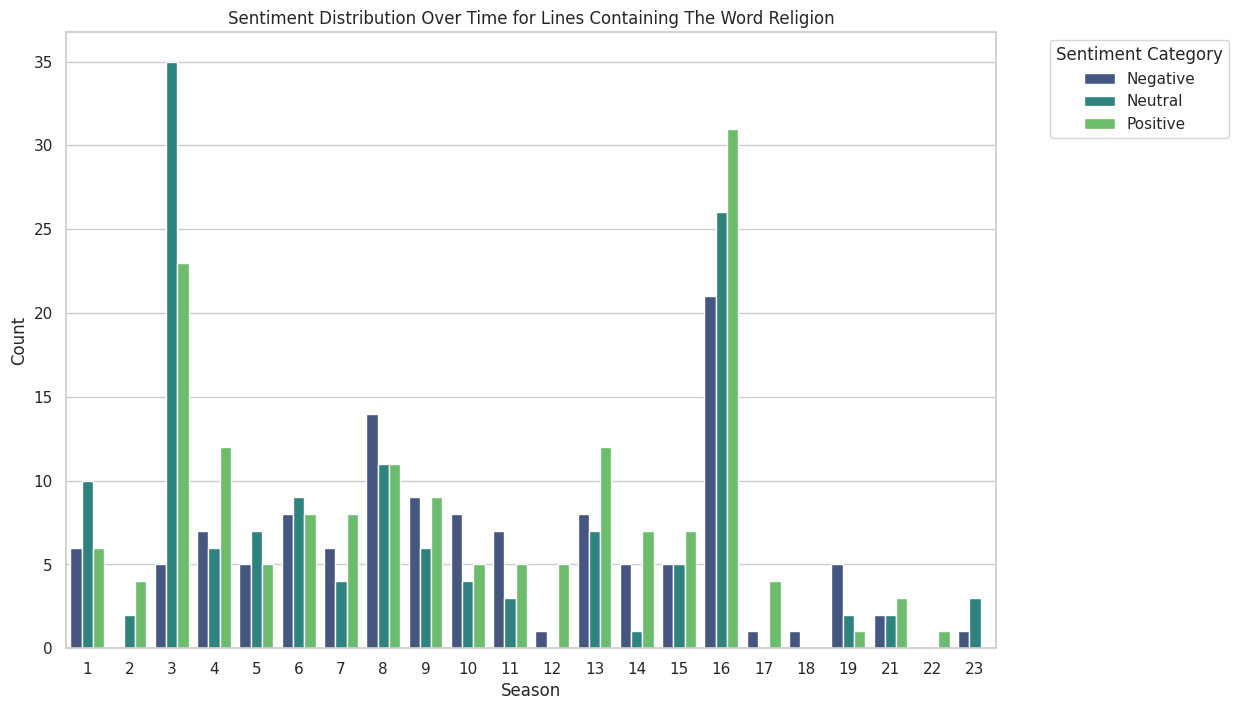

In [ ]:
religious_lines_df = merged_df[merged_df['Line'].str.contains('jew', case=False) & merged_df['Line'].notna()]
religious_lines_df['SentimentCategory'] = religious_lines_df['Line'].apply(get_sentiment)
plt.figure(figsize=(12, 8))
sns.countplot(x='Season', hue='SentimentCategory', data=religious_lines_df, palette='viridis')
plt.title('Sentiment Distribution Over Time for Lines Containing The Word Religion')
plt.xlabel('Season')
plt.ylabel('Count')
plt.legend(title='Sentiment Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

Although South Park has never been strongly against religion in general (as shown on the sentiment graph), mentions of religion in generally spark large amounts of discussion.

#🌈**Part 3: LGBTQ**

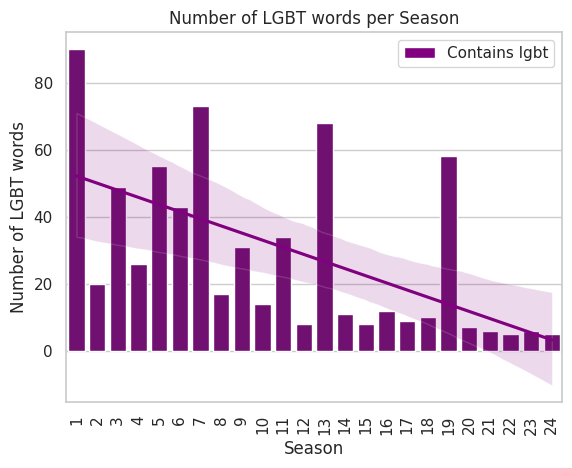

In [ ]:
lgbt_words = ['lgbtq', 'gay', 'lesbian', 'bisexual', 'transgender', 'queer',
    'pansexual', 'asexual', 'genderqueer', 'nonbinary', 'genderfluid',
    'homosexual', 'heterosexual', 'coming out', 'pride', 'lgbt']

def contains_lgbt(line):
    if pd.isna(line):
      return 0
    for j in lgbt_words:
      if j in line.lower(): return 1
    return 0

merged_df['Contains lgbt'] = merged_df['Line'].apply(contains_lgbt)
season_counts = merged_df.groupby('Season')['Contains lgbt'].sum()
season_counts.plot(kind='bar', color='purple')
sns.set(style="whitegrid")
ax = sns.barplot(x=season_counts.index, y=season_counts.values, color='purple')
sns.regplot(x=list(range(len(season_counts))), y=season_counts.values, ax=ax, scatter=False, color='purple', line_kws={'label': 'Regression Line'})
plt.xlabel('Season')
plt.ylabel('Number of LGBT words')
plt.title('Number of LGBT words per Season')
plt.legend()
plt.show()


Over time, the LGBTQ+ topic has become increasingly normalized, thanks to heightened awareness and education about gender and sexuality, as well as significant legal advancements and protections for the LGBTQ+ community. In its earlier seasons, South Park often used LGBTQ+ themes as a popular comedic device, leveraging the taboo nature of the subject at that time. The show introduced LGBTQ+ characters who were portrayed as genuinely good people, advocating for gay rights.

However, the show's reduced focus on LGBTQ+ topics in more recent seasons could suggest a shift in priorities, reflecting the broader acceptance of LGBTQ+ individuals in today's society. This change may also be attributed to a decrease in the shock factor and comedic value associated with LGBTQ+ themes, as they have become less controversial and more mainstream.

<ipython-input-29-2aaf2ad2eb26>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gay_lines_df['SentimentCategory'] = gay_lines_df['Line'].apply(get_sentiment)


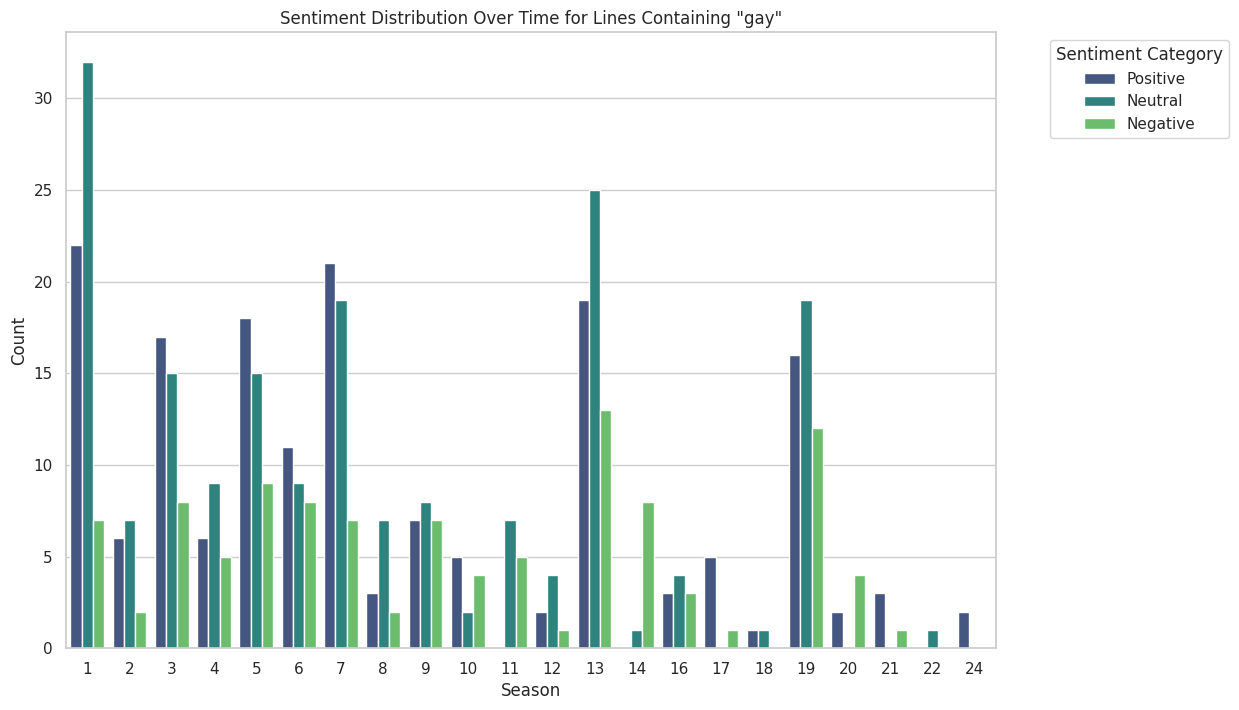

In [ ]:
gay_lines_df = merged_df[merged_df['Line'].str.contains('Gay', case=False) & merged_df['Line'].notna()]
gay_lines_df['SentimentCategory'] = gay_lines_df['Line'].apply(get_sentiment)
plt.figure(figsize=(12, 8))
sns.countplot(x='Season', hue='SentimentCategory', data=gay_lines_df, palette='viridis')
plt.title('Sentiment Distribution Over Time for Lines Containing "gay"')
plt.xlabel('Season')
plt.ylabel('Count')
plt.legend(title='Sentiment Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

As South Park has consistently embraced a positive stance towards the LGBTQ+ community, the emergence of negative sentiment might indicate a shift towards the normalization of making jokes about the subject, without the risk of the general audience misinterpreting South Park as being against it.

#🇺🇸**Part 4: Politics**

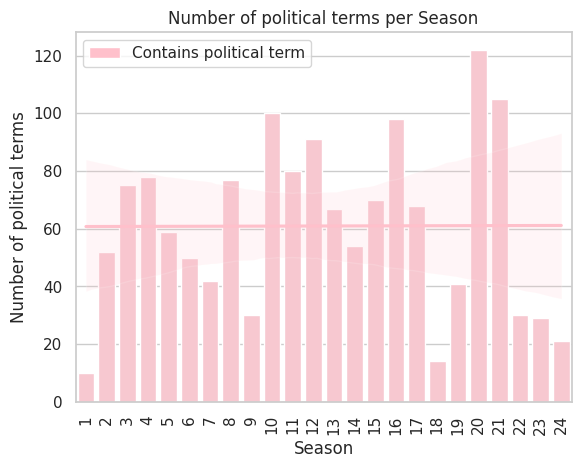

In [ ]:
political_terms = [
    "democracy", "government", "election", "vote", "policy",
    "law", "constitution", "obama", "clinton", "trump", "mccain"
    "sovereignty", "diplomacy", "civil rights", "political party",
    "candidate", "activism", "feminism", "ideology", "conservatism",
    "liberal", "socialism", "capitalism", "anarchy", "federalism",
    "separation of powers", "first amendment", "checks and balances",
    "president", "congress", "senate", "parliament", "monarchy",
    "dictatorship", "treaty", "impeachment", "corruption", "nationalism",
    "globalization", "media bias", "national security", "PC"
]

def contains_political_term(line):
    if pd.isna(line):
      return 0
    for j in political_terms:
      if j in line.lower(): return 1
    return 0

merged_df['Contains political term'] = merged_df['Line'].apply(contains_political_term)
season_counts = merged_df.groupby('Season')['Contains political term'].sum()
season_counts.plot(kind='bar', color='pink')
sns.set(style="whitegrid")
ax = sns.barplot(x=season_counts.index, y=season_counts.values, color='pink')
sns.regplot(x=list(range(len(season_counts))), y=season_counts.values, ax=ax, scatter=False, color='pink', line_kws={'label': 'Regression Line'})
plt.xlabel('Season')
plt.ylabel('Number of political terms')
plt.title('Number of political terms per Season')
plt.legend()
plt.show()

Since the regression line remains nearly constant throughout the entire graph, this could imply that, unlike the previous topics, politics is an omnipresent source of relevance and comedy in our society. As politics embodies decisions that affect the lives of all people every day, it will always be a controversial and relevant topic that will always rile others up and spark matters of discussion.

<ipython-input-31-c6b45699c6de>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  president_lines_df['SentimentCategory'] = president_lines_df['Line'].apply(get_sentiment)


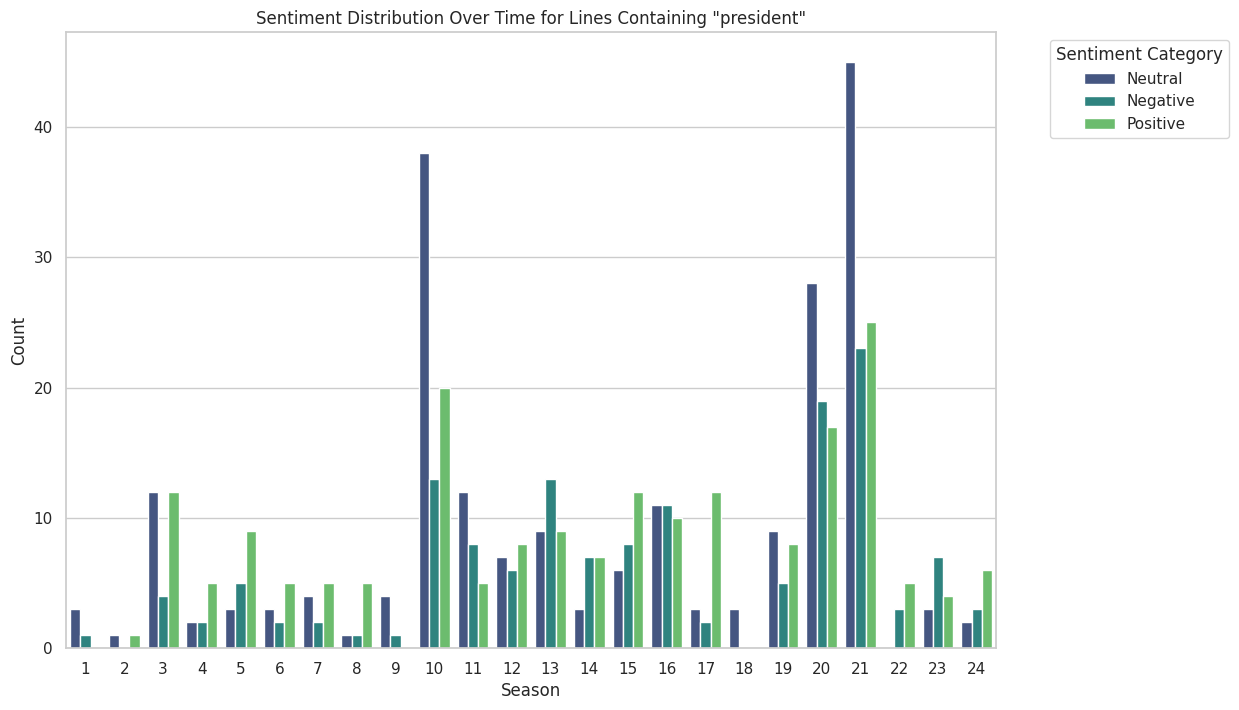

In [ ]:
president_lines_df = merged_df[merged_df['Line'].str.contains('president', case=False) & merged_df['Line'].notna()]
president_lines_df['SentimentCategory'] = president_lines_df['Line'].apply(get_sentiment)
plt.figure(figsize=(12, 8))
sns.countplot(x='Season', hue='SentimentCategory', data=president_lines_df, palette='viridis')
plt.title('Sentiment Distribution Over Time for Lines Containing "president"')
plt.xlabel('Season')
plt.ylabel('Count')
plt.legend(title='Sentiment Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

The graph above demonstrates how South Park dialogues demonstrate positive, neutral, negative sentiments surrounding the word "President". This may be due to South Park equally poking fun at both sides, garnering attention from both.

# 💻 **Densensitization of Certain Topics and its Correlation to Access to the Internet**

Dataset: https://www.kaggle.com/datasets/pavan9065/internet-usage

In [ ]:
internet_df = pd.read_csv('number-of-internet-users-by-country.csv')
internet_df = internet_df[internet_df['Entity'].str.contains('United States', case=False, na=False)]
internet_df = internet_df[internet_df['Entity'] != 'United States Virgin Islands']

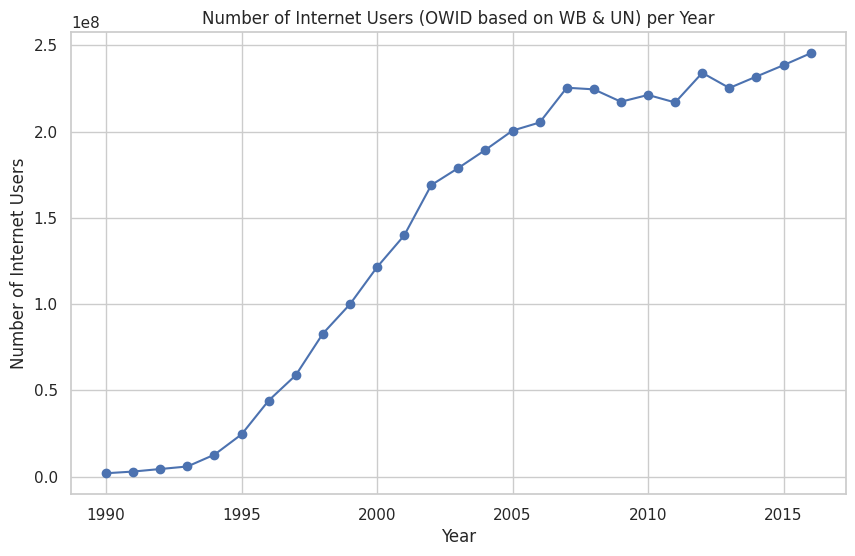

In [ ]:
internet_df = internet_df.groupby('Year')['Number of internet users (OWID based on WB & UN)'].sum().reset_index()
plt.figure(figsize=(10, 6))
plt.plot(internet_df['Year'], internet_df['Number of internet users (OWID based on WB & UN)'], marker='o', linestyle='-', color='b')
plt.title('Number of Internet Users (OWID based on WB & UN) per Year')
plt.xlabel('Year')
plt.ylabel('Number of Internet Users')
plt.grid(True)
plt.show()

As more and more people become more exposed to a wide range of content through the internet, social media, and various media platforms, they may develop a certain level of desensitization to shocking events. What was once considered shocking may become more normalized as individuals encounter diverse and sometimes extreme content regularly.

# 🤓 **Conclusion**




***South Park Recognizes Desensitization***

In the episode "It Hits the Fan," South Park cleverly illustrates how frequent use of the word "shit" on national television diminishes its impact over time, leading to desensitization among viewers. Recognizing this phenomenon, the show actively avoids redundancy and staleness by staying abreast of current trends. It constantly seeks innovative ways to deliver shock humor, ensuring that its content remains fresh and engaging for the audience.

***Does densensitization mean that shock humor is a dying form of humor?***

Even though South Park and similar shows strive to sustain shock humor by satirizing current and sensitive events across 24 seasons, this approach eventually becomes predictable and formulaic. The rapid expansion of internet usage has led to a widespread accessibility to diverse content, making shock-based humor less impactful for upcoming sitcoms. Future generations of sitcoms might find it necessary to explore alternative forms of humor to resonate with audiences effectively.








# 💡**What's Next?**

Three things that I really wanted to implement but were longer-term projects:


*   Scraping from IMDB to pair user reviews and ratings with analyses
*   Emotion Analyses to see if character reactions/responses to certain situations have become more mild over time
*   Comparing my South Park findings with other animated sitcoms such as Family Guy to see if it also had similar trends, which would validate my conclusion (couldn't find a dataset or script so this would be something I could spend a longer time looking for)





Thanks for reading!

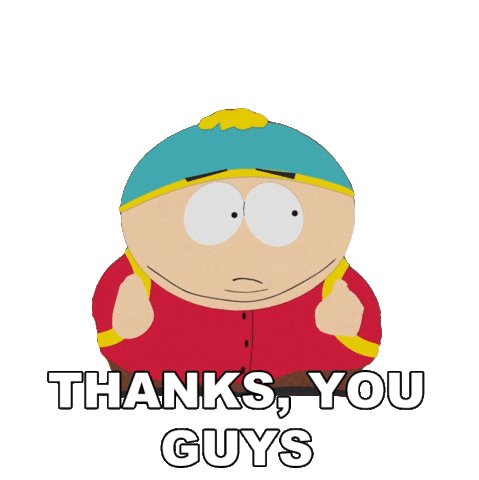



---





---



# **Some of my Rough Drafts and Experiments That Didn't Make it Into the Final Analysis**

Link to Seinfield Notebook that led me to be curious about South Park Data:
https://colab.research.google.com/drive/1wVgEeEKR5uN4ALmoEeKKcH6t5d0Isd5Q?usp=sharing

# **👩Lines Given to Female Characters**

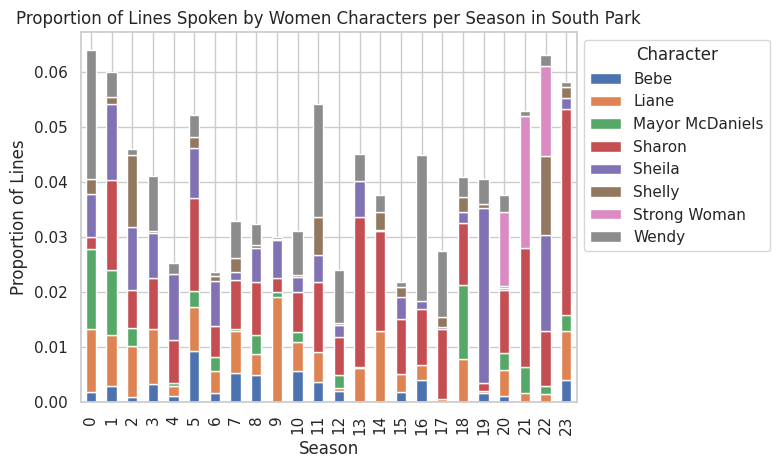

In [ ]:
women_characters = ["Wendy", "Bebe", "Sharon", "Sheila", "Liane", "Shelly", "Strong Woman", "Mayor McDaniels"]
women_df = merged_df[merged_df['Character'].isin(women_characters)]
women_lines_per_season = women_df.groupby(['Season', 'Character']).size().unstack()
total_lines_per_season = merged_df.groupby('Season')['Line'].count().reset_index()

women_lines_per_season=women_lines_per_season.fillna(0)
women_lines_per_season=women_lines_per_season.reset_index(drop=True)
women_lines_per_season = women_lines_per_season.div(total_lines_per_season['Line'].values, axis=0)

women_lines_per_season.plot(kind='bar', stacked=True)
plt.xlabel('Season')
plt.ylabel('Proportion of Lines')
plt.title('Proportion of Lines Spoken by Women Characters per Season in South Park')
plt.legend(title='Character', bbox_to_anchor=(1, 1))
plt.show()

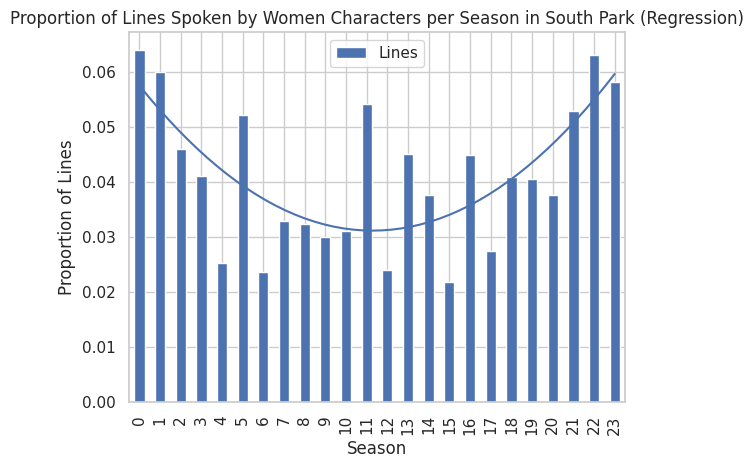

In [ ]:
total_women_lines_per_season = pd.DataFrame(women_lines_per_season.sum(axis=1))

total_women_lines_per_season = total_women_lines_per_season.rename(columns={0:'Lines'}).reset_index(drop=True)
indexed = total_women_lines_per_season.reset_index()
quad_fit = np.poly1d(np.polyfit(indexed['index'], indexed['Lines'], 2))
x = np.linspace(0,23,50)
ax = total_women_lines_per_season.plot(kind='bar', stacked=True)
ax.plot(x, quad_fit(x))

plt.xlabel('Season')
plt.ylabel('Proportion of Lines')
plt.title('Proportion of Lines Spoken by Women Characters per Season in South Park (Regression)')
plt.show()

Let's compare it to Seinfield, a popular sitcom in the late 1900s

In [ ]:
seinfield_df = pd.read_csv('scripts.csv')
seinfield_df.head(5)

FileNotFoundError: [Errno 2] No such file or directory: 'scripts.csv'

In [ ]:
women_characters = ["ELAINE", "SUSAN", "HELEN", "GWEN", "DOLORES", "SUE", "ELLEN", "NINA", "MARLENE", "NINA"]
women_df = seinfield_df[seinfield_df['Character'].isin(women_characters)]
women_lines_per_season = women_df.groupby(['Season', 'Character']).size().unstack()
total_lines_per_season = seinfield_df.groupby('Season')['Dialogue'].count().reset_index()

women_lines_per_season=women_lines_per_season.fillna(0)
women_lines_per_season=women_lines_per_season.reset_index(drop=True)
women_lines_per_season = women_lines_per_season.div(total_lines_per_season['Dialogue'].values, axis=0)

women_lines_per_season.plot(kind='bar', stacked=True)
plt.xlabel('Season')
plt.ylabel('Proportion of Lines')
plt.title('Proportion of Lines Spoken by Women Characters per Season on Seinfield')
plt.legend(title='Character', bbox_to_anchor=(1, 1))
plt.show()

In [ ]:
character_line_count = merged_df.groupby('Character')['Line'].count().reset_index()
character_line_count_sorted = character_line_count.sort_values(by='Line', ascending=False)
top_10_characters = character_line_count_sorted.head(11)

analysis_df = pd.DataFrame({
    'Character': top_10_characters['Character'],
    'Lines Spoken': top_10_characters['Line'],
    'Percentage of Total Lines': (top_10_characters['Line'] / len(merged_df)) * 100
})
analysis_df = analysis_df[analysis_df['Character'] != 'Scene Description']

analysis_df

South Park focuses on the absurdity and extremes in society, and this approach may contribute to the lack of a balanced representation of genders.


The graphs above emphasize how female dialogue make up a maximum of 6% of all lines per season. The regression graph emphasizes how this percentage takes a dip towards the middle seasons, and has since been climbing higher again. This may be due to South Park gradually reintroducing these female characters in an attempt to introduce more diverse dynamics and perspecties, as well as increased awareness.



This lack of female representation in the comedic realm is not only prominent in South Park, as other series, such as other modern series, such as Rick and Morty or Family Guy, which may imply a prejudiced bias towards male characters delivering powerful punchlines over female characters.

In [ ]:
most_common_keywords_per_title_df=most_common_keywords_per_title.apply(pd.Series).reset_index()
most_common_keywords_per_title_df

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()
for _, row in merged_df.iterrows():
    characters = row['Character'].split(', ')
    for i in range(len(characters) - 1):
        character1 = characters[i]
        character2 = characters[i + 1]
        if G.has_edge(character1, character2):
            G[character1][character2]['weight'] += 1
        else:
            G.add_edge(character1, character2, weight=1)

pos = nx.spring_layout(G)
edge_labels = {(n1, n2): d['weight'] for n1, n2, d in G.edges(data=True)}

plt.figure(figsize=(20, 20))
nx.draw_networkx_nodes(G, pos, node_size=700, node_color='skyblue')
nx.draw_networkx_edges(G, pos, width=[d['weight'] for u, v, d in G.edges(data=True)], edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=10, font_color='black')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', font_size=8)

plt.title('Character Relationships in South Park')
plt.show()

In [ ]:
total_seasons = len(seasons)
rows = int(total_seasons / 3) + (total_seasons % 3 > 0)
cols = min(total_seasons, 3)

fig, axes = plt.subplots(rows, cols, figsize=(30, 30), sharex=True, sharey=True)

for i, ax in enumerate(axes.flatten()):
    if i < total_seasons:
        season_number = seasons[i]
        season_df = merged_df[merged_df['Season'] == season_number]
        season_graph = nx.DiGraph()
        for _, row in season_df.iterrows():
            characters = row['Character'].split(', ')
            for i in range(len(characters) - 1):
                character1 = characters[i]
                character2 = characters[i + 1]
                if season_graph.has_edge(character1, character2):
                    season_graph[character1][character2]['weight'] += 1
                else:
                    season_graph.add_edge(character1, character2, weight=1)

        pos = nx.spring_layout(season_graph)
        edge_labels = {(n1, n2): d['weight'] for n1, n2, d in season_graph.edges(data=True)}

        nx.draw_networkx_nodes(season_graph, pos, node_size=700, node_color='skyblue', ax=ax)
        nx.draw_networkx_edges(season_graph, pos, width=[d['weight'] for u, v, d in season_graph.edges(data=True)], edge_color='gray', ax=ax)
        nx.draw_networkx_labels(season_graph, pos, font_size=10, font_color='black', ax=ax)
        nx.draw_networkx_edge_labels(season_graph, pos, edge_labels=edge_labels, font_color='red', font_size=8, ax=ax)

        ax.set_title(f'Season {season_number}')

for i in range(total_seasons, rows * cols):
    fig.delaxes(axes.flatten()[i])

plt.tight_layout()
plt.show()